In [6]:
DATA_URL="hf://datasets/VashuTheGreat2/E-Commerce-Product-Recommendation/data.csv"

In [7]:
rndom_state=142



In [8]:
import torch

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd

df = pd.read_csv(DATA_URL)
df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,id,product_search_description,name,variant,brand,price,discounted_price,usage,image_url
0,15970,men apparel topwear shirts navy blue fall casu...,Turtle Check Men Navy Blue Shirt,Check,Turtle,1195.0,1195.0,Casual,http://assets.myntassets.com/v1/images/style/p...
1,39386,men apparel bottomwear jeans blue summer casua...,Peter England Men Party Blue Jeans,Peter England Party Jeans,Peter England,1499.0,1499.0,Casual,http://assets.myntassets.com/v1/images/style/p...
2,59263,women accessories watches watches silver winte...,Titan Women Silver Watch,Titan Watches,Titan,6500.0,6500.0,Casual,http://assets.myntassets.com/v1/images/style/p...
3,21379,men apparel bottomwear track pants black fall ...,Manchester United Men Solid Black Track Pants,Solid,Manchester United,1699.0,1699.0,Casual,http://assets.myntassets.com/v1/images/style/p...
4,53759,men apparel topwear tshirts grey summer casual...,Puma Men Grey T-shirt,T-shirt,Puma,1099.0,1099.0,Casual,http://assets.myntassets.com/v1/images/style/p...
...,...,...,...,...,...,...,...,...,...
44441,17036,men footwear shoes casual shoes white summer c...,Gas Men Caddy Casual Shoe,Caddy,GAS,3000.0,3000.0,Casual,http://assets.myntassets.com/v1/images/style/p...
44442,6461,men footwear flip flops flip flops red summer ...,Lotto Men's Soccer Track Flip Flop,SOCCER TRACK,Lotto,499.0,499.0,Casual,http://assets.myntassets.com/v1/images/style/p...
44443,18842,men apparel topwear tshirts blue fall casual p...,Puma Men Graphic Stellar Blue Tshirt,Graphic,Puma,799.0,799.0,Casual,http://assets.myntassets.com/v1/images/style/p...
44444,46694,women personal care fragrance perfume and body...,Rasasi Women Blue Lady Perfume,BLUE LADY PART 2,Rasasi,850.0,850.0,Casual,http://assets.myntassets.com/v1/images/style/p...


In [11]:
df=df.sample(4480)


In [12]:

import os
import requests
import ast
from concurrent.futures import ThreadPoolExecutor

BASE_PATH = "/content/drive/MyDrive/data/images"
downloaded = 0
failed = 0
total_files = df.shape[0]


os.makedirs(BASE_PATH,exist_ok=True)

def save_images(row):
    global downloaded, failed

    image_id = row.id
    p = os.path.join(BASE_PATH, f"{image_id}.png")

    print(f"\rDownloaded: {downloaded}/{total_files} | Failed: {failed}/{total_files}", end="")

    if os.path.exists(p):
        downloaded += 1
        return

    try:
        image_url = row["image_url"]

        r = requests.get(image_url, timeout=10)
        r.raise_for_status()

        with open(p, "wb") as f:
            f.write(r.content)

        downloaded += 1

    except Exception as e:
        print(str(e),image_url)
        failed += 1

with ThreadPoolExecutor(max_workers=10) as executor:
    list(executor.map(save_images, [row for _, row in df.iterrows()]))

Downloaded: 4470/4480 | Failed: 0/4480

In [13]:
df['image_path']=[os.path.join(BASE_PATH,f"{id}.png") for id in df['id']]

In [14]:
df

,id,product_search_description,name,variant,brand,price,discounted_price,usage,image_url,image_path
17115,9084,women apparel bottomwear track pants grey fall...,ADIDAS Women Ess Cuffed Pant Grey Trackpant,ESS CUFFED PANT,ADIDAS,1399.0,1399.0,Sports,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/9084.png
12073,29882,men accessories eyewear sunglasses brown winte...,Mayhem Men Aviator Sunglasses 1019-201,Casual,Mayhem,1840.0,772.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/29882.png
24569,24291,men apparel topwear sweatshirts grey melange f...,Quick Silver Men Grey Melange Zip-up Sweatshirt,Solid,Quiksilver,3595.0,3595.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/24291.png
26754,59091,women apparel innerwear bra white summer casua...,Peri Peri Women White Bra,Second nature,Peri Peri,429.0,429.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/59091.png
11878,11821,men footwear shoes casual shoes black summer c...,Playboy Men Casual Black Casual Shoes,Casual,Playboy,1395.0,627.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/11821.png
...,...,...,...,...,...,...,...,...,...,...
40571,14646,men apparel topwear tshirts maroon fall casual...,Probase Men Funky Music Maroon Tshirts,Funky Music,Probase,399.0,399.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/14646.png
27835,50636,men apparel innerwear innerwear vests grey mel...,Chromozome Men Grey Melange Innerwear Vest,S-3193 Square Neck Vest,Chromozome,269.0,269.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/50636.png
36776,13349,women apparel bottomwear jeans blue fall casua...,Spykar Women Washed Blue Jeans,Washed,SPYKAR,1999.0,1999.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/13349.png
38723,10759,unisex footwear flip flops flip flops pink win...,Disney Unisex Kids Mini Mouse Pink Flip Flops,Kids Mini Mouse,Disney,229.0,229.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/10759.png


In [15]:
df.isna().sum()

,0
id,0
product_search_description,0
name,2
variant,1
brand,0
price,0
discounted_price,0
usage,31
image_url,0
image_path,0


In [16]:
df.dropna(inplace=True)

In [17]:
df

,id,product_search_description,name,variant,brand,price,discounted_price,usage,image_url,image_path
17115,9084,women apparel bottomwear track pants grey fall...,ADIDAS Women Ess Cuffed Pant Grey Trackpant,ESS CUFFED PANT,ADIDAS,1399.0,1399.0,Sports,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/9084.png
12073,29882,men accessories eyewear sunglasses brown winte...,Mayhem Men Aviator Sunglasses 1019-201,Casual,Mayhem,1840.0,772.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/29882.png
24569,24291,men apparel topwear sweatshirts grey melange f...,Quick Silver Men Grey Melange Zip-up Sweatshirt,Solid,Quiksilver,3595.0,3595.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/24291.png
26754,59091,women apparel innerwear bra white summer casua...,Peri Peri Women White Bra,Second nature,Peri Peri,429.0,429.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/59091.png
11878,11821,men footwear shoes casual shoes black summer c...,Playboy Men Casual Black Casual Shoes,Casual,Playboy,1395.0,627.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/11821.png
...,...,...,...,...,...,...,...,...,...,...
40571,14646,men apparel topwear tshirts maroon fall casual...,Probase Men Funky Music Maroon Tshirts,Funky Music,Probase,399.0,399.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/14646.png
27835,50636,men apparel innerwear innerwear vests grey mel...,Chromozome Men Grey Melange Innerwear Vest,S-3193 Square Neck Vest,Chromozome,269.0,269.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/50636.png
36776,13349,women apparel bottomwear jeans blue fall casua...,Spykar Women Washed Blue Jeans,Washed,SPYKAR,1999.0,1999.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/13349.png
38723,10759,unisex footwear flip flops flip flops pink win...,Disney Unisex Kids Mini Mouse Pink Flip Flops,Kids Mini Mouse,Disney,229.0,229.0,Casual,http://assets.myntassets.com/v1/images/style/p...,/content/drive/MyDrive/data/images/10759.png


In [18]:
import numpy as np

df_positive = df[['image_path', 'product_search_description']].copy()
df_positive['label'] = 1.0

df_negative = df[['image_path']].copy()
df_negative['product_search_description'] = np.roll(df['product_search_description'].values, shift=1)
df_negative['label'] = 0.0

train_df = pd.concat([df_positive, df_negative], ignore_index=True)

train_df = train_df.sample(frac=1,random_state=rndom_state).reset_index(drop=True)

In [19]:
train_df

,image_path,product_search_description,label
0,/content/drive/MyDrive/data/images/43577.png,unisex accessories bags duffel bag blue summer...,0.0
1,/content/drive/MyDrive/data/images/22071.png,women apparel saree sarees pink fall ethnic fn...,0.0
2,/content/drive/MyDrive/data/images/21165.png,men apparel bottomwear shorts black summer spo...,0.0
3,/content/drive/MyDrive/data/images/52950.png,women apparel saree sarees purple fall ethnic ...,1.0
4,/content/drive/MyDrive/data/images/34640.png,men footwear shoes casual shoes blue summer ca...,1.0
...,...,...,...
8889,/content/drive/MyDrive/data/images/50319.png,men apparel topwear tshirts navy blue spring s...,0.0
8890,/content/drive/MyDrive/data/images/34269.png,men apparel innerwear briefs white summer casu...,0.0
8891,/content/drive/MyDrive/data/images/12217.png,men accessories watches watches black winter c...,0.0
8892,/content/drive/MyDrive/data/images/37902.png,men apparel topwear tshirts blue spring casual...,0.0


In [20]:
import torchvision.models as models
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision.transforms import v2
from transformers import AutoTokenizer, AutoModel
import cv2
from dataclasses import dataclass
import random
import os
from tqdm.auto import tqdm

@dataclass
class Config:
    max_len: int = 128
    image_feature_output: int = 2048
    text_feature_output: int = 768
    feature_expand_dim: int = (2048 + 768) * 2
    final_feature_output: int = 512
    learning_rate: float = 0.0001
    model_name: str = "multimodal_model.pt"
    model_dir: str = "checkpoints"
    epochs: int = 20
    patience: int = 3
    batch_size: int = 32
    dropout: float = 0.6
    cache_dir: str = "./drive/MyDrive/.mm_catch"

class ImageEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.image_encoder = nn.Sequential(*list(resnet.children())[:-1])

        for param in self.image_encoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            x = self.image_encoder(x)
            x = torch.flatten(x, 1)
        return x

class TextEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.text_model = AutoModel.from_pretrained("sentence-transformers/all-mpnet-base-v2")

        for param in self.text_model.parameters():
            param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
            text_vector = outputs.last_hidden_state[:, 0, :]
        return text_vector

class MLPModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.model = nn.Sequential(
            nn.Linear(self.config.image_feature_output + self.config.text_feature_output, self.config.image_feature_output // 2),
            nn.ReLU(),
            nn.Dropout(self.config.dropout),
            nn.Linear(self.config.image_feature_output // 2, self.config.final_feature_output),
            nn.ReLU()
        )
        self.classifier = nn.Linear(self.config.final_feature_output, 1)

    def forward(self, x, return_embedding=False):
        embedding = self.model(x)
        if return_embedding:
            return nn.functional.normalize(embedding, p=2, dim=1)
        return self.classifier(embedding)

class Multimodal(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.mlp = MLPModel(config=config)

    def forward(self, img_feats, text_feats, return_embedding=False):
        combined = torch.cat((img_feats, text_feats), dim=1)
        return self.mlp(combined, return_embedding=return_embedding)


class MultimodalDataset(Dataset):
    def __init__(self, data_frame, config=Config(), indices=None, device=None):
        super().__init__()
        self.data_frame = data_frame.reset_index(drop=True)
        self.config = config
        self.indices = indices if indices is not None else list(range(len(self.data_frame)))

        # Explicit device allocation (Default to CUDA if active)
        self.device = device if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.img_cache_path = os.path.join(self.config.cache_dir, "img_feats.pt")
        self.txt_cache_path = os.path.join(self.config.cache_dir, "txt_feats.pt")
        self.lbl_cache_path = os.path.join(self.config.cache_dir, "labels.pt")

        # Build cache globally once if it doesn't exist
        if not (os.path.exists(self.img_cache_path) and os.path.exists(self.txt_cache_path) and os.path.exists(self.lbl_cache_path)):
            self._build_global_cache()

        # CUDA FIX: map_location ko self.device kar diya taaki tensors direct GPU RAM par load hon
        print(f"Loading cached tensors directly onto {self.device}...")
        self.img_features = torch.load(self.img_cache_path, map_location=self.device)
        self.text_features = torch.load(self.txt_cache_path, map_location=self.device)
        self.labels = torch.load(self.lbl_cache_path, map_location=self.device)

    def _build_global_cache(self):
        os.makedirs(self.config.cache_dir, exist_ok=True)

        tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
        image_encoder = ImageEncoder(self.config).to(self.device).eval()
        text_encoder = TextEncoder(self.config).to(self.device).eval()

        transforms = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Resize(size=(224, 224), antialias=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        num_samples = len(self.data_frame)
        all_img_feats = torch.zeros((num_samples, self.config.image_feature_output), dtype=torch.float32)
        all_txt_feats = torch.zeros((num_samples, self.config.text_feature_output), dtype=torch.float32)
        all_labels = torch.tensor(self.data_frame['label'].values, dtype=torch.float32)

        print(f"--- Cache matrix not found. Building block arrays for {num_samples} samples on {self.device} ---")
        for i in tqdm(range(num_samples), desc="Caching Features"):
            img_path = self.data_frame.loc[i, 'image_path']
            text = str(self.data_frame.loc[i, 'product_search_description'])

            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_tensor = transforms(img).unsqueeze(0).to(self.device)
                img_feat = image_encoder(img_tensor).cpu()
            except Exception:
                img_feat = torch.zeros((1, self.config.image_feature_output), dtype=torch.float32)

            tokens = tokenizer(
                text,
                padding='max_length',
                max_length=self.config.max_len,
                truncation=True,
                return_tensors="pt"
            ).to(self.device)

            txt_feat = text_encoder(tokens['input_ids'], tokens['attention_mask']).cpu()

            all_img_feats[i] = img_feat.squeeze(0)
            all_txt_feats[i] = txt_feat.squeeze(0)

        torch.save(all_img_feats, self.img_cache_path)
        torch.save(all_txt_feats, self.txt_cache_path)
        torch.save(all_labels, self.lbl_cache_path)
        print("--- Global embedding matrix cached successfully! ---")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        actual_idx = self.indices[index]

        img_tensor = self.img_features[actual_idx].clone()
        txt_tensor = self.text_features[actual_idx].clone()
        label = self.labels[actual_idx]

        if label == 1.0:
            dropout_rand = random.random()
            if dropout_rand < 0.15:
                # Modality dropout zeroes are allocated on the exact same tensor device configuration
                img_tensor = torch.zeros(self.config.image_feature_output, dtype=torch.float32, device=self.device)
            elif dropout_rand < 0.30:
                txt_tensor = torch.zeros(self.config.text_feature_output, dtype=torch.float32, device=self.device)

        return img_tensor, txt_tensor, label

In [21]:
config = Config()
model = Multimodal(config=config)

# Image feature dimension config se (2048-d)
sample_test_img_feats = torch.randn(size=(1, config.image_feature_output))

# Text feature dimension config se (768-d)
sample_test_text_feats = torch.randn(size=(1, config.text_feature_output))

# Forward pass me sirf ye dono vector matrices pass honge
output = model(sample_test_img_feats, sample_test_text_feats)

print("Output Shape:", output.shape) # Output should be torch.Size([1, 1])
print(output)

Output Shape: torch.Size([1, 1])
tensor([[0.2488]], grad_fn=<AddmmBackward0>)


In [22]:
from tqdm.auto import tqdm
import torch
import os

class Model:
    def __init__(self, config):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = Multimodal(config=config).to(self.device)
        self.optimizer = torch.optim.Adam(params=self.model.parameters(), lr=self.config.learning_rate)

        pos_weight_val = train_df[train_df['label'] == 0].shape[0] / (train_df[train_df['label'] == 1].shape[0] + 1e-5)
        pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(self.device)
        self.loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

        self.train_loss = []
        self.val_loss = []
        self.best_val_loss = float('inf')
        self.patience_counter = 0

    def train(self, train_data_loader, val_data_loader):
        self.load_model()
        for epoch in range(self.config.epochs):
            self.model.train()
            train_loss = 0.0

            train_pbar = tqdm(train_data_loader, desc=f"Epoch {epoch+1}/{self.config.epochs} [Train]", leave=False)
            for img_feats, text_feats, labels in train_pbar:
                img_feats = img_feats.to(self.device)
                text_feats = text_feats.to(self.device)
                labels = labels.to(self.device).unsqueeze(1)

                self.optimizer.zero_grad()
                outputs = self.model(img_feats, text_feats)
                loss = self.loss_fn(outputs, labels)

                loss.backward()
                self.optimizer.step()

                train_loss += loss.item()
                train_pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

            avg_train_loss = train_loss / len(train_data_loader)
            avg_val_loss = self.validate(val_data_loader)

            self.train_loss.append(avg_train_loss)
            self.val_loss.append(avg_val_loss)

            print(f"Epoch [{epoch+1}/{self.config.epochs}] -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

            if avg_val_loss < self.best_val_loss:
                self.best_val_loss = avg_val_loss
                self.patience_counter = 0
                self.save_model()
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.config.patience:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    break

    def validate(self, val_data_loader):
        self.model.eval()
        val_loss = 0.0

        val_pbar = tqdm(val_data_loader, desc="Validating", leave=False)
        with torch.no_grad():
            for img_feats, text_feats, labels in val_pbar:
                img_feats = img_feats.to(self.device)
                text_feats = text_feats.to(self.device)
                labels = labels.to(self.device).unsqueeze(1)

                outputs = self.model(img_feats, text_feats)
                loss = self.loss_fn(outputs, labels)

                val_loss += loss.item()
                val_pbar.set_postfix({"val_batch_loss": f"{loss.item():.4f}"})

        return val_loss / len(val_data_loader)

    def predict(self, img_feats, text_feats):
        self.model.eval()
        with torch.no_grad():
            img_feats = img_feats.to(self.device)
            text_feats = text_feats.to(self.device)

            logits = self.model(img_feats, text_feats)
            probs = torch.sigmoid(logits)
        return probs

    def save_model(self):
        os.makedirs(self.config.model_dir, exist_ok=True)
        checkpoint_path = os.path.join(self.config.model_dir, self.config.model_name)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_loss': self.best_val_loss,
            'train_loss': self.train_loss,
            'val_loss': self.val_loss
        }, checkpoint_path)

    def load_model(self):
        checkpoint_path = os.path.join(self.config.model_dir, self.config.model_name)
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=self.device)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            self.best_val_loss = checkpoint.get('best_val_loss', float('inf'))
            self.train_loss = checkpoint.get('train_loss', [])
            self.val_loss = checkpoint.get('val_loss', [])

In [23]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=rndom_state,
    stratify=train_df['label'] # to have same percentage of the data as it was in the original data
)

train_df_final, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    random_state=rndom_state,
    stratify=train_val_df['label'],

)

In [24]:
print(train_df_final.shape)
print(val_df.shape)
print(test_df.shape)

(6224, 3)
(1335, 3)
(1335, 3)


In [25]:
from torch.utils.data import DataLoader

train_df_loader = DataLoader(MultimodalDataset(train_df_final),batch_size=config.batch_size)
val_df_loader = DataLoader(MultimodalDataset(val_df),batch_size=config.batch_size)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

--- Cache matrix not found. Building block arrays for 6224 samples on cuda ---


Caching Features:   0%|          | 0/6224 [00:00<?, ?it/s]

--- Global embedding matrix cached successfully! ---
Loading cached tensors directly onto cuda...
Loading cached tensors directly onto cuda...


In [26]:
myModel=Model(config=config)

In [27]:
myModel.train(train_data_loader=train_df_loader,val_data_loader=val_df_loader)

Epoch 1/20 [Train]:   0%|          | 0/195 [00:00<?, ?it/s]

Validating:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch [1/20] -> Train Loss: 0.6738 | Val Loss: 0.6046


Epoch 2/20 [Train]:   0%|          | 0/195 [00:00<?, ?it/s]

Validating:   0%|          | 0/42 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch [19/20] -> Train Loss: 0.0702 | Val Loss: 0.0606


Epoch 20/20 [Train]:   0%|          | 0/195 [00:00<?, ?it/s]

Validating:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch [20/20] -> Train Loss: 0.0664 | Val Loss: 0.0525


Text(0, 0.5, 'Loss')

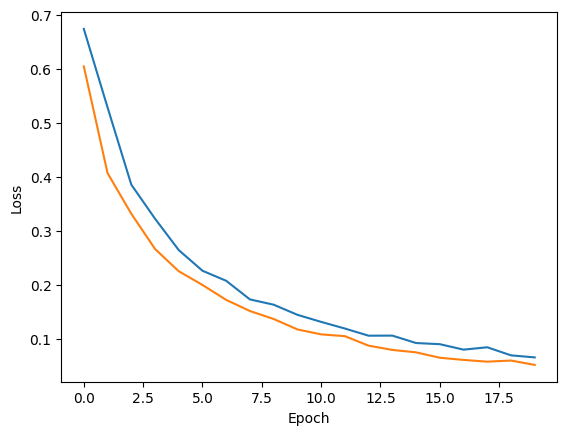

In [28]:

import matplotlib.pyplot as plt

plt.plot(myModel.train_loss, label='Train Loss')
plt.plot(myModel.val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Accessing as vanshsharma7832

Initialized MLflow to track repo "vanshsharma7832/E-Commerce-Chatbot-recommendation"

Repository vanshsharma7832/E-Commerce-Chatbot-recommendation initialized!

2026/06/20 07:11:40 INFO mlflow.tracking.fluent: Experiment with name 'E-Commerce-Chatbot-Recommendation-Experiment-20260620-071140' does not exist. Creating a new experiment.


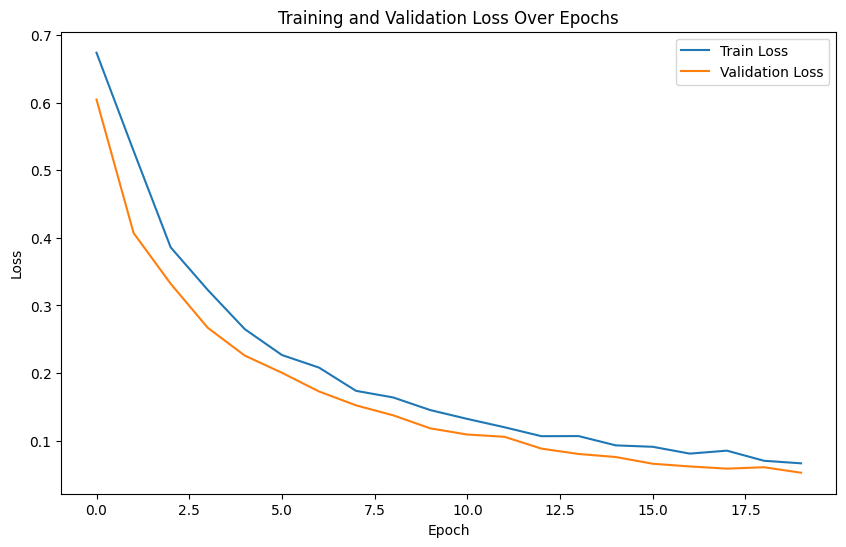

Loading cached tensors directly onto cuda...


Evaluating on Test Set:   0%|          | 0/42 [00:00<?, ?it/s]


               TEST SET PERFORMANCE               
Accuracy  : 0.9745
Precision : 0.9556
Recall    : 0.9938
F1-Score  : 0.9744



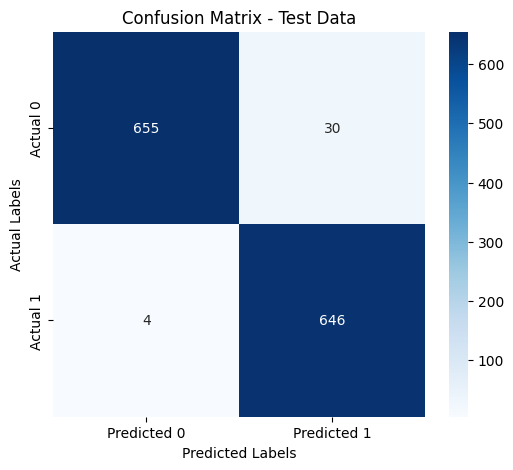

2026/06/20 07:11:49 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/20 07:11:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/20 07:12:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version la

Successfully registered model tracking schemas on remote servers.
🏃 View run Multimodal_Training_Run at: https://dagshub.com/vanshsharma7832/E-Commerce-Chatbot-recommendation.mlflow/#/experiments/17/runs/54973dd7844b486289076f74e1f3a816
🧪 View experiment at: https://dagshub.com/vanshsharma7832/E-Commerce-Chatbot-recommendation.mlflow/#/experiments/17


In [29]:
!pip install dagshub mlflow

import dagshub
dagshub.auth.add_app_token("fee29b0c9f88f7918ad1474919b54153acd45f5e")
dagshub.init(repo_owner='vanshsharma7832', repo_name='E-Commerce-Chatbot-recommendation', mlflow=True)

import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from datetime import datetime
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch

from dataclasses import  asdict

# Set the MLflow experiment name with a unique identifier
experiment_name = f"E-Commerce-Chatbot-Recommendation-Experiment-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
mlflow.set_experiment(experiment_name)

myModel.load_model()
log_to_mlflow = True

with mlflow.start_run(run_name="Multimodal_Training_Run"):

    # 1. PEHLE MODEL KO TRAIN KARO
    # myModel.train(train_loader, val_loader)

    # 2. GRAPH GENERATE AUR METRICS LOG KARO
    if hasattr(myModel, 'train_loss') and len(myModel.train_loss) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(myModel.train_loss, label='Train Loss')
        if hasattr(myModel, 'val_loss') and len(myModel.val_loss) > 0:
            plt.plot(myModel.val_loss, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Over Epochs')
        plt.legend()

        plot_path = "loss_plot.png"
        plt.savefig(plot_path)
        plt.show()
        plt.close()

        mlflow.log_artifact(plot_path)

        avg_train_loss = myModel.train_loss[-1]
        mlflow.log_metric("train_loss", avg_train_loss)

        if hasattr(myModel, 'val_loss') and len(myModel.val_loss) > 0:
            avg_val_loss = myModel.val_loss[-1]
            mlflow.log_metric("val_loss", avg_val_loss)

        if os.path.exists(plot_path):
            os.remove(plot_path)



    # 3. TEST SET PERFORMANCE EVALUATION (CACHED INPUT FIX)
    test_dataset = MultimodalDataset(data_frame=test_df, config=myModel.config)
    test_loader = DataLoader(
        test_dataset,
        batch_size=getattr(myModel.config, 'batch_size', 32),
        shuffle=False
    )

    myModel.model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        # Loop ko naye cached feature variables ke format par fix kiya h
        for img_feats, text_feats, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
            img_feats = img_feats.to(myModel.device)
            text_feats = text_feats.to(myModel.device)

            logits = myModel.model(img_feats, text_feats)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int().cpu().numpy().flatten()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print("\n" + "="*50)
    print("               TEST SET PERFORMANCE               ")
    print("="*50)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("="*50 + "\n")

    # Heatmap Generation
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.title('Confusion Matrix - Test Data')
    plt.ylabel('Actual Labels')
    plt.xlabel('Predicted Labels')

    cm_plot_path = "confusion_matrix.png"
    plt.savefig(cm_plot_path, bbox_inches='tight')
    plt.show()
    plt.close()

    if log_to_mlflow:
        mlflow.log_artifact(cm_plot_path)
        mlflow.log_metric("test_accuracy", accuracy)
        mlflow.log_metric("test_f1_score", f1)
        mlflow.log_metric("test_precision", precision)
        mlflow.log_metric("test_recall", recall)
        mlflow.log_params(asdict(config))

        if os.path.exists(cm_plot_path):
            os.remove(cm_plot_path)

    # 4. MLFLOW PYTORCH MODEL LOGGING & REGISTRY SYNC (FIXED FOR PT2 / TRACE GRAPH ERROR)
    if hasattr(myModel, 'model'):
        # Shape check wale variables use karke exact inputs ka example banaya
        # Batch size 1 ka dummy feature vector jo direct model accept karega

        # MLflow warning ke mutabik: artifact_path ki jagah now 'name' parameter use kiya h
        try:
            model_info = mlflow.pytorch.log_model(
                pytorch_model=myModel.model,
                name="multimodal_model_registry",
                serialization_format='pickle' # Explicitly setting to 'pickle'
            )

            # # Model Registry mapping logic
            # mlflow.register_model(model_uri, "E-Commerce-Multimodal-Encoder")
            print("Successfully registered model tracking schemas on remote servers.")

        except Exception as e:
            # Fallback block: Agar DagsHub server registered_model_name ko reject kare toh normal log ho jaye
            print(f"Direct Registry skipped, attempting normal logging fallback due to: {e}")
            model_info = mlflow.pytorch.log_model(
                pytorch_model=myModel.model,
                name="multimodal_model_registry",
                serialization_format='pickle' # Explicitly setting to 'pickle'
            )
    else:
        print("Warning: Trained PyTorch model object not found inside myModel wrapper.")